# <span style="color:green"> Lecture 12 notebook </span>

## <span style="color:blue"> Exercise 12.1 </span>

 ### Optimzer: **sgd**

In [12]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

In [48]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


X_train shape: (60000, 784)
X_test shape: (10000, 784)

an example of a data point with label 4


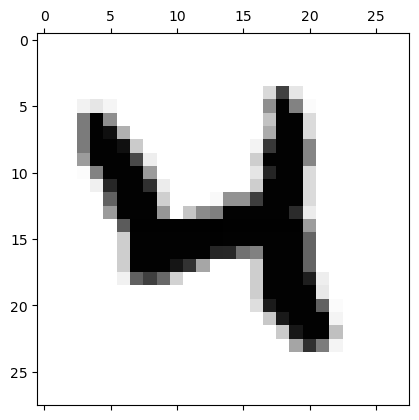

... and with label [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.] after to_categorical

X_train shape: (60000, 784)
Y_train shape: (60000, 10)


In [50]:
# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print()

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
X_train /= 255
X_test /= 255

# look at an example of data point
print('an example of a data point with label', Y_train[20])
# matshow: display a matrix in a new figure window
plt.matshow(X_train[20,:].reshape(28,28),cmap='binary')
plt.show()

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)
print('... and with label', Y_train[20], 'after to_categorical')
print()
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

In [16]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


In [17]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=SGD(),
                  metrics=['acc'])
    return model

print('Model compiled successfully and ready to be trained.')

Model compiled successfully and ready to be trained.


In [18]:
# training parameters
batch_size = 32
epochs = 40

# create the deep neural net
model_DNN = compile_model()

# train DNN and store training info in history
history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          verbose=0,
          validation_data=(X_test, Y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9808 - loss: 0.0593

Test loss: 0.05927073210477829
Test accuracy: 0.9807999730110168


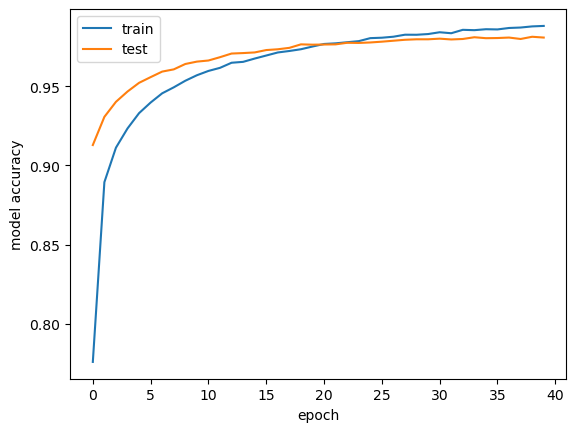

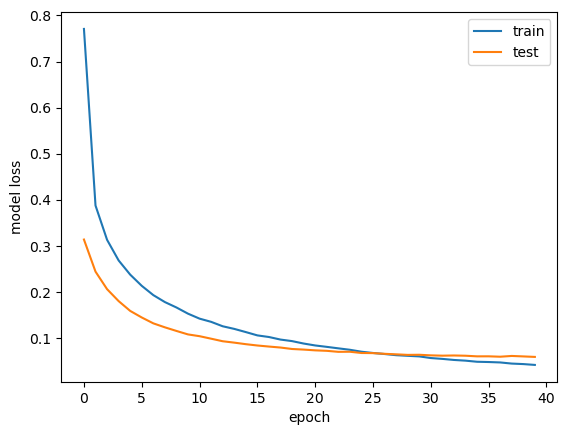

In [19]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


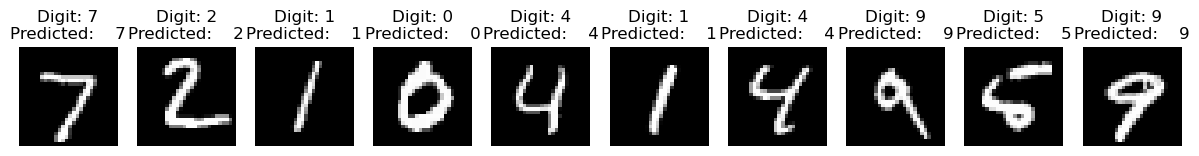

In [20]:
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

 ### Optimzer: **Adam**, default arguments

Ho provato a utilizzare l'optimizer **adam** con i relativi iperparametri di default. Le descrizioni degli optimizers sono state prese al link https://keras.io/api/optimizers/

In [28]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    
    model=create_DNN()

    custom_adam = Adam(
        learning_rate=0.001, 
        beta_1=0.9, 
        beta_2=0.999, 
        epsilon=1e-07
    )
    
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=custom_adam,
                  metrics=['acc'])
    return model

In [33]:


batch_size = 32
epochs = 40

model_DNN = compile_model()

history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, 
          verbose=0,
          validation_data=(X_test, Y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9810 - loss: 0.1845

Test loss: 0.18449091911315918
Test accuracy: 0.9810000061988831


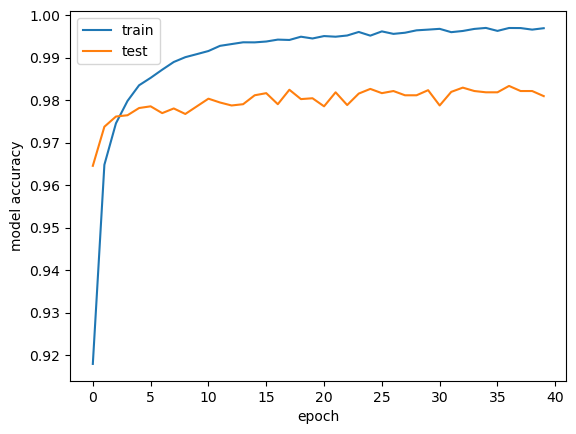

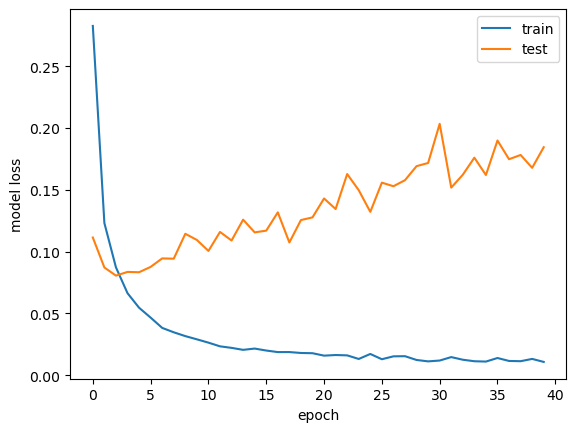

In [34]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Osserviamo come il modello sembri andare in overfitting piuttosto presto, già intorno alla quinta epoch. L'accuracy resta comunque alta, quindi nel test di correttezza sottostante mi aspetto comunque una buona performance. 

Probabilmente **Adam**, essendo ottimizzatore adattivo, è andato troppo veloce nel riconoscere i pattern e poi ha overfittato per il resto del tempo.

Per limitare questo effetto, proverò con **AdamW**, che ha un parametro weight decay, che penalizza quando pesi troppo grandi sono asssegnati ai neuroni.

Aumento anche la batch_size, il che dovrebbe accelerare i calcoli e non danneggiare apprendimento su un dataset così grande.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


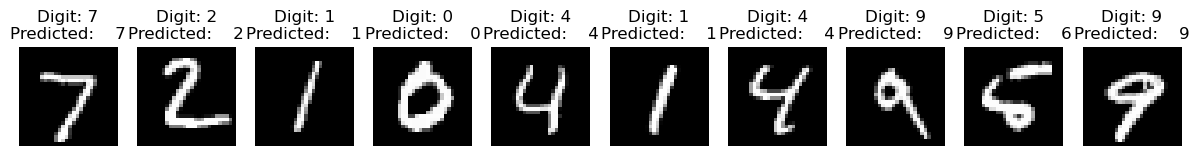

In [35]:
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

 ### Optimzer: **AdamW**, weight_decay = 0.005

In [43]:
from keras.optimizers import SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    
    model=create_DNN()

    custom_adam = AdamW(
        learning_rate=0.001, 
        weight_decay=0.005,
        beta_1=0.9, 
        beta_2=0.999, 
        epsilon=1e-07
    )
    
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=custom_adam,
                  metrics=['acc'])
    return model

In [45]:


batch_size = 128
epochs = 40

model_DNN = compile_model()

history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, 
          verbose=0,
          validation_data=(X_test, Y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9820 - loss: 0.1211

Test loss: 0.12112602591514587
Test accuracy: 0.9819999933242798


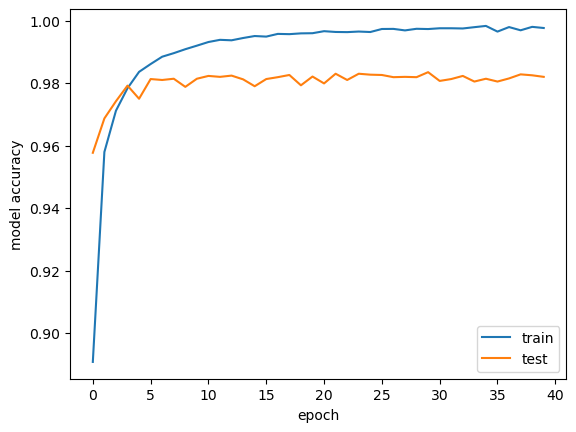

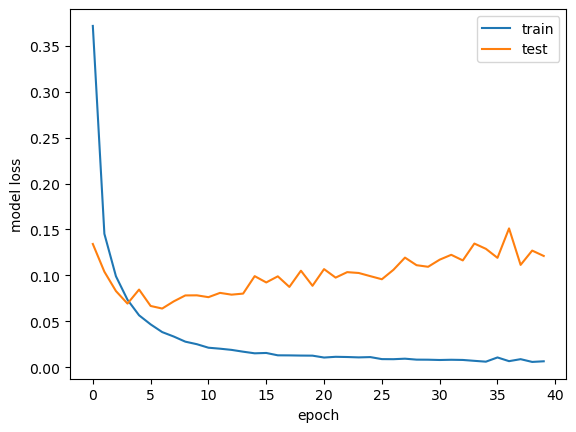

In [46]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Sebbene il modello vada ancora chiaramente in overfitting, possiamo osservare la capacità del weight_decay in **AdamW** di smorzare la risalita della test loss rispetto all'optimizer **Adam**. Forse, per migliorare questo effetto, si potrebbe incrementare il valore di weight_decay fino a $0.001$ o diminuire il learning_rate.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


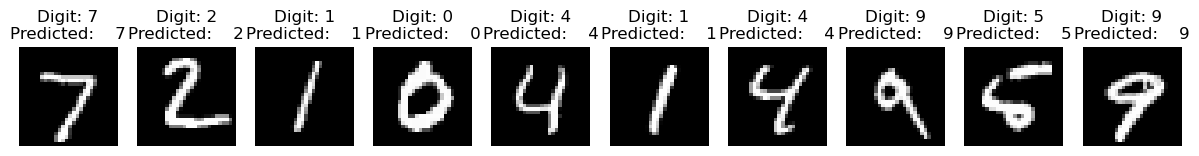

In [47]:
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

 ### Optimzer: **RMSprop**, default arguments

In [51]:
from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adam, Adamax, Nadam

def compile_model():
    
    model=create_DNN()

    custom_RMS = RMSprop(
        learning_rate=0.001,
        rho=0.9,
        momentum=0.0,
        epsilon=1e-07
    )
    
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=custom_RMS,
                  metrics=['acc'])
    return model

In [52]:
batch_size = 256
epochs = 30

model_DNN = compile_model()

history = model_DNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True, 
          verbose=0,
          validation_data=(X_test, Y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9833 - loss: 0.0940

Test loss: 0.09402069449424744
Test accuracy: 0.983299970626831


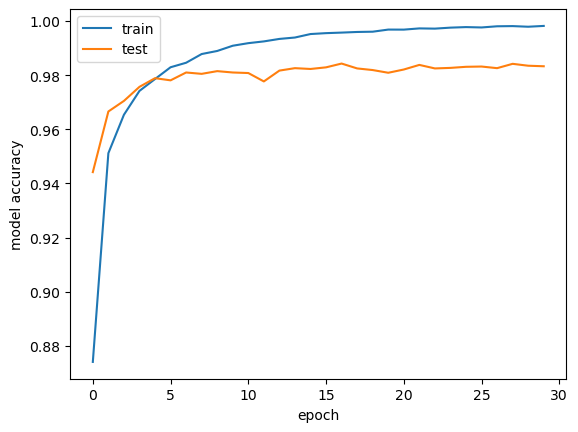

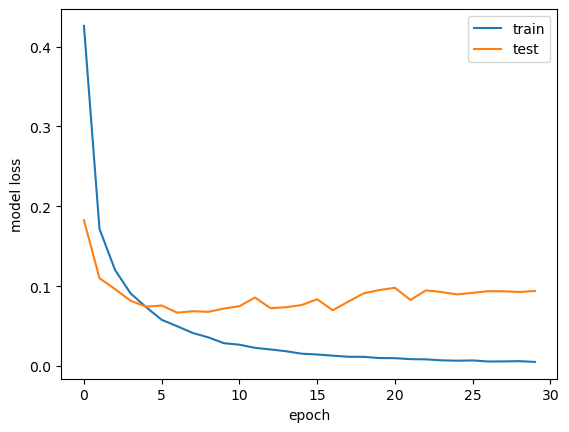

In [53]:
# evaluate model
score = model_DNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Anche con questo optimizer, la rete raggiunge il suo minimo piuttosto in fretta, andando incontro a un processo, seppur non drammatico, di overfitting. Potremmo considerare l'introduzione di un early_stop per evitare di sprecare tempo e perdere accuracy utilizzando troppe epoche.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


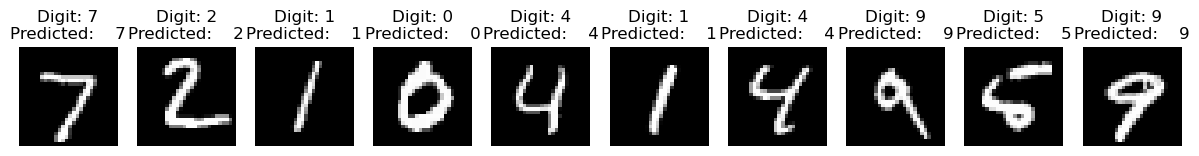

In [54]:
predictions = model_DNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

## <span style="color:blue"> Exercise 12.2 </span>

In [91]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)


In [92]:
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

In [94]:
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [95]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input


def create_CNN():
   
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(20, kernel_size=(5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten('channels_first'))
        
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='SGD',
                  metrics=['acc'])
    return model

In [96]:
# training parameters
batch_size = 256
epochs = 18# INSERT HERE AN ADEQUATE NUMBER OF EPOCHS!

# create the deep conv net
model_CNN=create_CNN()

# train CNN
history = model_CNN.fit(X_train, Y_train,
          batch_size=batch_size,
          epochs=epochs,
          shuffle=True,
          verbose=0,
          validation_data=(X_test, Y_test))

# evaliate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9636 - loss: 0.1131

Test loss: 0.11309174448251724
Test accuracy: 0.9635999798774719


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9636 - loss: 0.1131

Test loss: 0.11309174448251724
Test accuracy: 0.9635999798774719


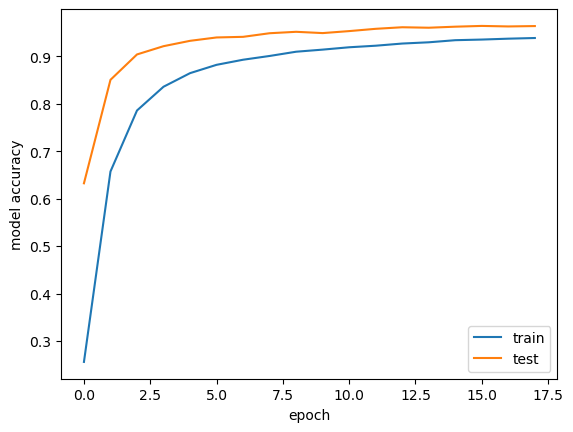

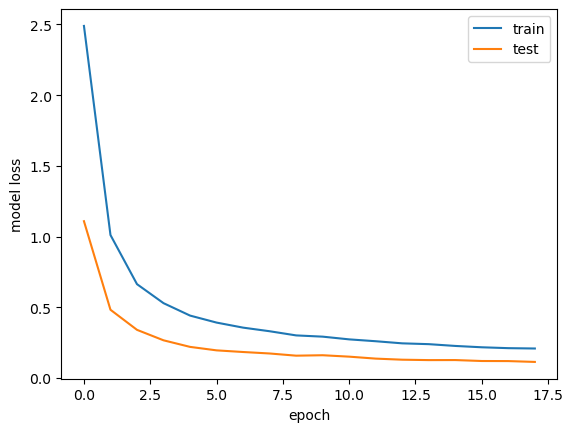

In [97]:
# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


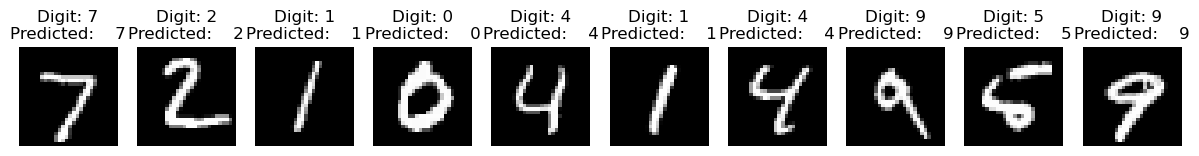

In [98]:
predictions = model_CNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

Dopo qualche tentativo, ho notato che la struttura della rete che sembra avere risultati migliori prevede un andamento a imbuto, come nel caso della DNN, con una forte variazione negativa del numero di neuroni nell'ultima parte, quella composta di layer 'Dense'. 

Ho riscontrato anche l'importanza della funzioen 'Dropout', che permette di spegnere una frazione prestabilita dei neuroni per evitare che il sistema si fossilizzi su determinate corrispondenze andando in overfitting.

Ho anch variato i parametri del pooling 2D, e notato che aumentare molto la dimensione del pool non migliora le prestazini della rete, portando spesso a peggiorarle.

## <span style="color:blue"> Exercise 12.3 </span>

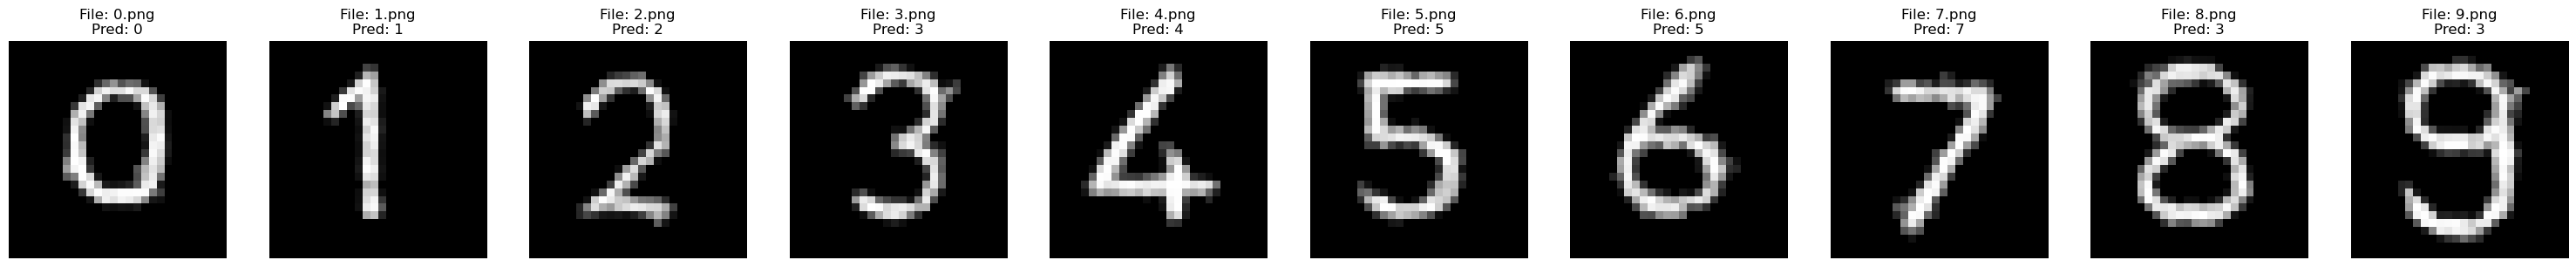

In [104]:
import os
from PIL import Image


folder_path = "./cifre"

image_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]
image_files.sort()


fig, axes = plt.subplots(1, len(image_files), figsize=(3 * len(image_files), 3))

if len(image_files) == 1:
    axes = [axes]

for ax, filename in zip(axes, image_files):
    img_path = os.path.join(folder_path, filename)
    
    digit_in = Image.open(img_path).convert('L')
    
    data = np.array(digit_in) / 255.0
    data[data < 0.05] = 0.0
    data = data*255
    xdim, ydim = data.shape

    data_cnn = data.reshape(1, xdim, ydim, 1)
    
    pred = model_CNN.predict(data_cnn, verbose=0) 
    predicted_digit = np.argmax(pred)
    
    ax.imshow(data, cmap='gray')
    ax.set_title(f"File: {filename}\nPred: {predicted_digit}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Possiamo notare come la rete sembri avere qualche difficoltà in più a riconoscere i numeri scritti da me, probabilmente a causa dello spessore del tratto, che sembra minore di quello utilizzato del dataset MNIST.